In [4]:
# Content-Based Recommendation System
#This notebook continues from `Data_Cleaning.ipynb`.  
#The cleaned dataset `cleaned metadata.xlsx` will be used to build a content-based recommendation model for CBT (Community-Based Tourism) listings.

In [3]:
# Step 1: Load and inspect cleaned dataset

# Import required libraries
import pandas as pd

# Load cleaned data
df = pd.read_excel(r"C:\laragon\www\web\lokalkita\data\cleaned metadata .xlsx")

# Display basic info
print(" Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nColumns:\n", df.columns.tolist())

# Preview the data
df.head()


✅ Dataset loaded successfully!
Shape: (226, 20)

Columns:
 ['item_id', 'title', 'description', 'tags', 'category', 'location', 'state', 'min price (RM)', 'max price (RM)', 'operating hours', 'operating days', 'closing days', 'rating', 'host_id', 'host_name', 'contact', 'more_info', 'opening_time', 'closing_time', 'price_type']


,item_id,title,description,tags,category,location,state,min price (RM),max price (RM),operating hours,operating days,closing days,rating,host_id,host_name,contact,more_info,opening_time,closing_time,price_type
0,1,Ilham Ceramic Studio,"Ilham Seramik Studio showcases ceramic-making,...","ceramic, pottery, craft",Arts & Crafts,"Ilham Ceramic Studio, Kampung Bendang Baru, 07...",Kedah,8.0,518.0,9:00 AM - 5:00 PM,Daily,Friday,4.8,HO1,Radzi Ismail,013-599 4022,https://www.instagram.com/ilham_ceramic/?hl=en,09:00:00,17:00:00,Paid
1,2,Maklang Cafe By Ilham Ceramic Studio,Maklang Cafe by Ilham Ceramic offers cultural ...,"food, culinary, culture",Food & Culinary,"Ilham Ceramic Studio, Kampung Bendang Baru, 07...",Kedah,0.5,15.0,8:00 AM - 6:00 PM,Daily,Friday,4.8,HO1,Radzi Ismail,013-599 4022,https://naturallylangkawi.my/portfolio/ilham-s...,08:00:00,18:00:00,Paid
2,3,Perencah Mee Bandung Mak Pon,Perencah Mee Bandung Mak Pon offers varieties ...,"food, paste, culinary",Food & Culinary,"1, 2 & 3, Jalan Lembah Padang, Taman Lembah Pa...",Johor,12.0,30.0,10:00 AM - 7:00 PM,Daily,Not mentioned,4.0,HO2,JJ Makpon Muar,012-262 0044,https://shopee.com.my/Pes-Mee-Bandung-Muar-Mi-...,10:00:00,19:00:00,Paid
3,4,Pau Mira Frozen Food Pagoh,Pau Mira Frozen Food is a Malaysian brand offe...,"food, frozen_food, culinary",Food & Culinary,"KM13, Jalan Pagoh, 84600 Pagoh, Johor",Johor,9.2,15.0,8:00 AM - 6:00 PM,Daily,Friday,4.6,HO3,Pau Mira,012-743 4086,https://www.facebook.com/paugebulembut/,08:00:00,18:00:00,Paid
4,5,Galeri Terompah Mastor,Galeri Terompah Mastor specializes in handcraf...,"footwear, craft, woodwork",Arts & Crafts,"Kg. Parit Hassan, Simpang Renggam, Kluang, Johor",Johor,98.0,600.0,8:30 AM - 5:30 PM,Daily,Saturday,4.0,HO4,Galeri Terompah Mastor,6018-7649193,https://www.facebook.com/tourismjohor/posts/ga...,08:30:00,17:30:00,Paid


In [5]:
# Step 2: Combine relevant features into one text column

# Fill any remaining missing text values with empty string to avoid errors
df[['title', 'description', 'tags', 'category', 'state', 'price_type']] = (
    df[['title', 'description', 'tags', 'category', 'state', 'price_type']].fillna('')
)

# Combine into one column
df['combined_features'] = (
    df['title'] + ' ' +
    df['description'] + ' ' +
    df['tags'] + ' ' +
    df['category'] + ' ' +
    df['state'] + ' ' +
    df['price_type']
)

# Check result
df[['item_id', 'title', 'combined_features']].head(5)


,item_id,title,combined_features
0,1,Ilham Ceramic Studio,Ilham Ceramic Studio Ilham Seramik Studio show...
1,2,Maklang Cafe By Ilham Ceramic Studio,Maklang Cafe By Ilham Ceramic Studio Maklang C...
2,3,Perencah Mee Bandung Mak Pon,Perencah Mee Bandung Mak Pon Perencah Mee Band...
3,4,Pau Mira Frozen Food Pagoh,Pau Mira Frozen Food Pagoh Pau Mira Frozen Foo...
4,5,Galeri Terompah Mastor,Galeri Terompah Mastor Galeri Terompah Mastor ...


In [7]:
## Step 3: TF-IDF Vectorization
#Convert text data (`combined_features`) into numerical vectors using TF-IDF, which captures how relevant a word is to a specific listing compared to others.

from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english')

# Fit and transform the combined text
tfidf_matrix = tfidf.fit_transform(df['combined_features'])

# Display matrix shape
print("TF-IDF matrix shape:", tfidf_matrix.shape)


TF-IDF matrix shape: (226, 1515)


In [8]:
## Step 4: Compute Cosine Similarity
#Use cosine similarity to calculate how similar each listing is to every other listing based on TF-IDF vectors.
from sklearn.metrics.pairwise import cosine_similarity

# Compute similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(" Cosine similarity matrix shape:", cosine_sim.shape)


✅ Cosine similarity matrix shape: (226, 226)


In [11]:
## Step 5: Build Recommendation Function
#This function returns the top 5 most similar listings to a given item title.
import pandas as pd

# Reset index just in case
df = df.reset_index(drop=True)

# Create a Series to map titles to indices
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

def get_recommendations(title, cosine_sim=cosine_sim):
    # Get the index of the given title
    idx = indices[title]
    
    # Get pairwise similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    # Sort by similarity score (descending)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Skip the first (it’s the same item) and take top 5
    sim_scores = sim_scores[1:6]
    
    # Get indices of the 5 most similar items
    item_indices = [i[0] for i in sim_scores]
    
    # Return titles and similarity scores
    return df[['title', 'category', 'state', 'price_type']].iloc[item_indices].assign(similarity=[round(i[1], 3) for i in sim_scores])


In [13]:
#testing similarity
get_recommendations("Natural Batik Village")

,title,category,state,price_type,similarity
183,Pakmud Batik,Arts & Crafts,Selangor,Paid,0.494
212,Maskamal Batik & Trading,Arts & Crafts,Kelantan,Paid,0.489
31,Mybatik Art Gallery,Arts & Crafts,Selangor,Paid,0.436
115,Malaysian Batik Experience - Handkerchief,Arts & Crafts,Kuala Lumpur,Free / Not mentioned,0.436
30,Cwoks Batik Workshop,Arts & Crafts,Kuala Lumpur,Paid,0.423


In [15]:
#Fine Tuner
df['weighted_features'] = (
    df['title'] + ' ' +
    df['title'] + ' ' +  # weight title twice
    df['tags'] + ' ' + df['tags'] + ' ' +  # weight tags twice
    df['category'] + ' ' + 
    df['description'] + ' ' +
    df['state']
)

tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1,2))


In [17]:
tfidf_matrix = tfidf.fit_transform(df['weighted_features'])
cosine_sim = cosine_similarity(tfidf_matrix)


In [19]:
import matplotlib.pyplot as plt

def get_recommendations(item_name, df, cosine_sim, top_n=5, show_plot=True):
    """
    Generate top N content-based recommendations using cosine similarity.
    
    Parameters:
        item_name (str): Title of the item to find recommendations for.
        df (DataFrame): The dataset.
        cosine_sim (array): Cosine similarity matrix.
        top_n (int): Number of recommendations to return.
        show_plot (bool): Whether to visualize results.
    """
    # Find index of the selected item
    if item_name.lower() not in df['title'].str.lower().values:
        print(f"❌ '{item_name}' not found in dataset.")
        return None
    
    index = df[df['title'].str.lower() == item_name.lower()].index[0]
    
    # Compute similarity scores
    sim_scores = list(enumerate(cosine_sim[index]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Get top N (excluding itself)
    top_items = sim_scores[1:top_n+1]
    
    # Prepare results
    recommendations = df.iloc[[i[0] for i in top_items]][
        ['title', 'category', 'state', 'price_type']
    ].copy()
    recommendations['similarity'] = [i[1] for i in top_items]
    
    print(f"\n Top {top_n} recommendations for '{item_name}':\n")
    display(recommendations)
    
    # Optional visualization
    if show_plot:
        plt.figure(figsize=(8, 4))
        plt.barh(recommendations['title'], recommendations['similarity'], color='skyblue')
        plt.xlabel('Similarity Score')
        plt.title(f'Top {top_n} Recommendations for "{item_name}"')
        plt.gca().invert_yaxis()
        plt.show()
    
    return recommendations



🎯 Top 5 recommendations for 'Natural Batik Village':



,title,category,state,price_type,similarity
212,Maskamal Batik & Trading,Arts & Crafts,Kelantan,Paid,0.263150
183,Pakmud Batik,Arts & Crafts,Selangor,Paid,0.256743
30,Cwoks Batik Workshop,Arts & Crafts,Kuala Lumpur,Paid,0.227889
115,Malaysian Batik Experience - Handkerchief,Arts & Crafts,Kuala Lumpur,Free / Not mentioned,0.223849
34,Nordin Batik Sdn. Bhd,Arts & Crafts,Kelantan,Paid,0.216461


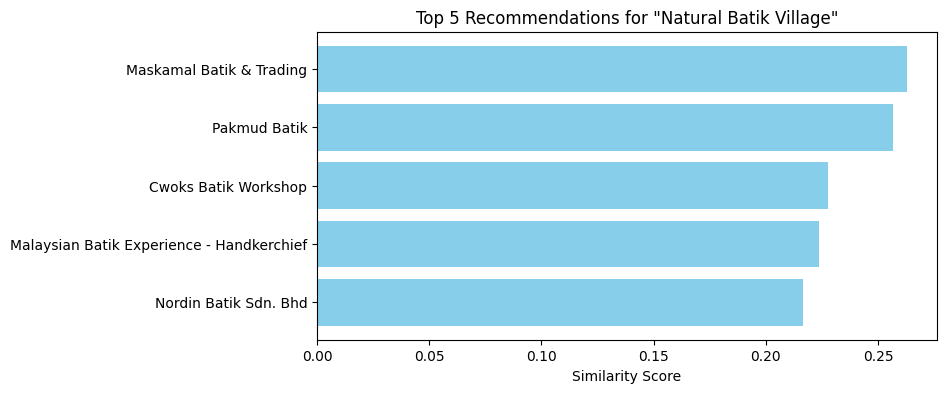

,title,category,state,price_type,similarity
212,Maskamal Batik & Trading,Arts & Crafts,Kelantan,Paid,0.263150
183,Pakmud Batik,Arts & Crafts,Selangor,Paid,0.256743
30,Cwoks Batik Workshop,Arts & Crafts,Kuala Lumpur,Paid,0.227889
115,Malaysian Batik Experience - Handkerchief,Arts & Crafts,Kuala Lumpur,Free / Not mentioned,0.223849
34,Nordin Batik Sdn. Bhd,Arts & Crafts,Kelantan,Paid,0.216461


In [20]:
get_recommendations("Natural Batik Village", df, cosine_sim, top_n=5)
